In [81]:
from pathlib import Path
import pandas as pd
import numpy as np 
from  sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import seaborn as sns

In [40]:
DATA_DIR = Path.cwd().parent / "data"
df = pd.read_csv(DATA_DIR / "processed" / "NYC_ride_cleaned.csv")
df.head(5)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,7.583333
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,11.050000
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,35.400000
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,7.150000
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,7.250000


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1446659 entries, 0 to 1446658
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1446659 non-null  str    
 1   vendor_id           1446659 non-null  int64  
 2   pickup_datetime     1446659 non-null  str    
 3   dropoff_datetime    1446659 non-null  str    
 4   passenger_count     1446659 non-null  int64  
 5   pickup_longitude    1446659 non-null  float64
 6   pickup_latitude     1446659 non-null  float64
 7   dropoff_longitude   1446659 non-null  float64
 8   dropoff_latitude    1446659 non-null  float64
 9   store_and_fwd_flag  1446659 non-null  str    
 10  trip_duration       1446659 non-null  float64
dtypes: float64(5), int64(2), str(4)
memory usage: 121.4 MB


In [42]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

Remove data leakage

In [41]:

df.drop(['vendor_id','dropoff_datetime','store_and_fwd_flag'],axis =1,inplace=True)

In [19]:
def haversine_form(lat1,long1,lat2,long2):
    lat1 , long1,lat2,long2 = map(np.radians, [lat1, long1, lat2, long2])
    dlat = lat2-lat1
    dlong = long2-long1
    a  = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2)*np.sin(dlong/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 3956
    return c*r

In [51]:
df['distance'] =  haversine_form(df['pickup_latitude'],df['pickup_longitude'],df['dropoff_latitude'],df['dropoff_longitude'])
df['day_of_week'] = df['pickup_datetime'].dt.day_of_week
df['pickup_hour'] = df['pickup_datetime'].dt.hour


In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1446659 entries, 0 to 1446658
Data columns (total 11 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   id                 1446659 non-null  str           
 1   pickup_datetime    1446659 non-null  datetime64[us]
 2   passenger_count    1446659 non-null  int64         
 3   pickup_longitude   1446659 non-null  float64       
 4   pickup_latitude    1446659 non-null  float64       
 5   dropoff_longitude  1446659 non-null  float64       
 6   dropoff_latitude   1446659 non-null  float64       
 7   trip_duration      1446659 non-null  float64       
 8   distance           1446659 non-null  float64       
 9   day_of_week        1446659 non-null  int32         
 10  pickup_hour        1446659 non-null  int32         
dtypes: datetime64[us](1), float64(6), int32(2), int64(1), str(1)
memory usage: 110.4 MB


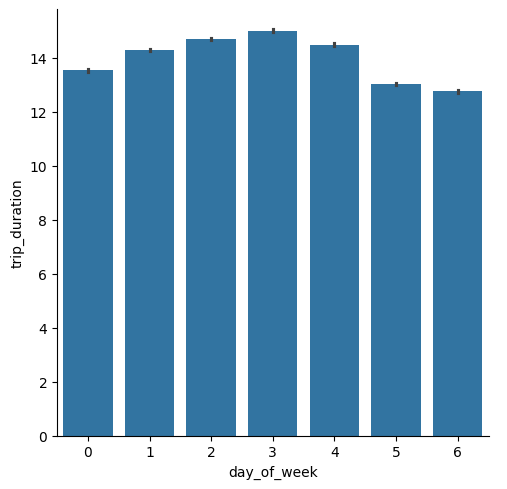

In [50]:
sns.catplot(df,x='day_of_week',y='trip_duration',kind='bar')

In [73]:
X = df.drop(['trip_duration','id','pickup_datetime'],axis=1)
y = df['trip_duration']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,shuffle=True)

In [74]:
pipeline= Pipeline([("scaler",StandardScaler()),
                    ("model",LinearRegression())])

In [84]:

pipeline.fit(X_train,y_train)
prediction = pipeline.predict(X_test)
print(f"Baseline Mean Absolute Error {mean_absolute_error(y_test,prediction):.2f}")
print(f"R2 {r2_score(y_test,prediction):.2f}")

Baseline Mean Absolute Error 4.68
R2 0.60


In [79]:
w = pipeline.named_steps["model"].coef_
col = X.columns

<Axes: ylabel='None'>

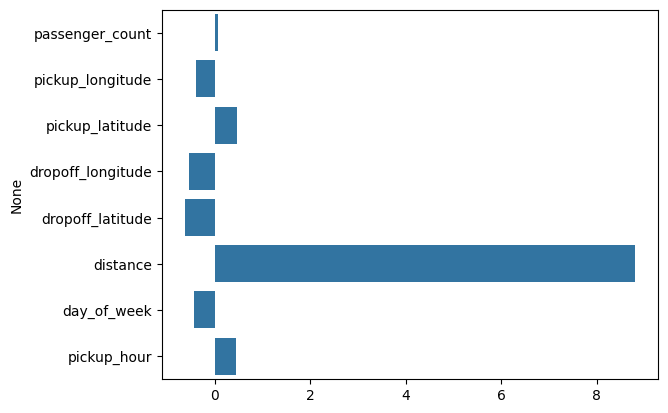

In [80]:
sns.barplot(x=w,y=col)

Distance having high weight can be understood since it has a linear relation ship with trip duration, the R2 score is 0.60 which explains 60% of variance
with 40% remaining unexplained mainly due to it consisting of non linear relationship